# NIVEL AVANZADO - Calidad de Datos con POO

Este notebook implementa un sistema de calidad de datos usando programación orientada a objetos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import Dict, List, Tuple, Any
from dataclasses import dataclass
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✅ Librerías cargadas correctamente")
print(f"📅 Análisis AVANZADO ejecutado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Librerías cargadas correctamente
📅 Análisis AVANZADO ejecutado: 2026-05-21 11:25:14


## Clases Base del Sistema

In [2]:
@dataclass
class ResultadoCalidad:
    """
    Clase para almacenar resultados de análisis de calidad.

    Attributes:
        dimension (str): Nombre de la dimensión de calidad evaluada
        registros_problematicos (pd.DataFrame): DataFrame con registros
            que tienen problemas de calidad
        total_registros (int): Total de registros en el dataset de
            municipalidades analizado
        descripcion (str): Descripción del problema encontrado
        severidad (str): Nivel de severidad (ALTA, MEDIA, BAJA)
    """
    dimension: str
    registros_problematicos: pd.DataFrame
    total_registros: int
    descripcion: str = ""
    severidad: str = "MEDIA"

    @property
    def cantidad_problemas(self) -> int:
        """Retorna la cantidad de registros con problemas"""
        return len(self.registros_problematicos)

    @property
    def porcentaje_afectado(self) -> float:
        """Calcula el porcentaje de registros de municipalidades afectados"""
        if self.total_registros == 0:
            return 0.0
        return (self.cantidad_problemas / self.total_registros) * 100

    def resumen(self) -> Dict[str, Any]:
        """
        Genera un resumen del resultado de calidad.

        Returns:
            dict: Diccionario con métricas clave del análisis
        """
        return {
            'dimensión':  self.dimension,
            'problemas':  self.cantidad_problemas,
            'porcentaje': round(self.porcentaje_afectado, 2),
            'severidad':  self.severidad
        }

In [3]:
class AnalizadorCalidadBase:
    """
    Clase base abstracta para analizadores de calidad de datos
    del proyecto de ingresos municipales MEF.

    Esta clase define la interfaz que deben implementar todos los
    analizadores de dimensiones específicas de calidad para los
    datasets SIAF, SISMEPRE y RENAMU.

    Attributes:
        df (pd.DataFrame): DataFrame a analizar (municipalidades)
        nombre_dimension (str): Nombre de la dimensión de calidad
    """

    def __init__(self, df: pd.DataFrame, nombre_dimension: str):
        """
        Inicializa el analizador de calidad.

        Args:
            df: DataFrame de pandas con los datos de ingresos
                municipales a analizar
            nombre_dimension: Nombre identificador de la dimensión
                de calidad (ej: 'Completitud', 'Exactitud')
        """
        self.df = df
        self.nombre_dimension = nombre_dimension
        self.resultados = []

    def analizar(self) -> List[ResultadoCalidad]:
        """
        Método abstracto que debe implementar cada analizador
        de dimensión de calidad.

        Returns:
            Lista de ResultadoCalidad con los problemas encontrados
            en el dataset de ingresos municipales
        """
        raise NotImplementedError("Subclases deben implementar este método")

    def _crear_resultado(
        self,
        registros: pd.DataFrame,
        descripcion: str,
        severidad: str = "MEDIA"
    ) -> ResultadoCalidad:
        """
        Crea un objeto ResultadoCalidad para un problema detectado
        en los datos de ingresos municipales.

        Args:
            registros: DataFrame con registros problemáticos
                encontrados en el dataset SIAF
            descripcion: Descripción del problema de calidad
                detectado (ej: 'MONTO_PIA negativo')
            severidad: Nivel de severidad del problema
                ('ALTA', 'MEDIA' o 'BAJA')

        Returns:
            Objeto ResultadoCalidad configurado con el problema
        """
        return ResultadoCalidad(
            dimension=self.nombre_dimension,
            registros_problematicos=registros,
            total_registros=len(self.df),
            descripcion=descripcion,
            severidad=severidad
        )

## Analizadores Específicos por Dimensión

In [4]:
class AnalizadorCompletitud(AnalizadorCalidadBase):
    """
    Analiza la completitud de los datos de ingresos municipales
    (valores faltantes en columnas clave del SIAF).

    La completitud mide si todos los campos requeridos tienen valores.
    Prioriza columnas críticas: NIVEL_GOBIERNO, EJECUTORA_NOMBRE,
    MONTO_PIA, MONTO_PIM, MONTO_RECAUDADO, RUBRO_NOMBRE.
    """

    # Columnas críticas para el análisis de municipalidades
    COLUMNAS_CRITICAS = [
        'NIVEL_GOBIERNO', 'NIVEL_GOBIERNO_NOMBRE',
        'EJECUTORA_NOMBRE', 'SEC_EJEC',
        'DEPARTAMENTO_EJECUTORA_NOMBRE',
        'RUBRO', 'RUBRO_NOMBRE',
        'FUENTE_FINANCIAMIENTO', 'FUENTE_FINANCIAMIENTO_NOMBRE',
        'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
    ]

    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Completitud")

    def analizar(self) -> List[ResultadoCalidad]:
        """
        Ejecuta el análisis de completitud sobre el dataset
        de ingresos municipales SIAF.

        Identifica columnas con valores faltantes, priorizando
        las columnas críticas para el análisis presupuestal.

        Returns:
            Lista de ResultadoCalidad, uno por cada columna
            con valores faltantes encontrada
        """
        resultados = []

        for columna in self.df.columns:
            faltantes = self.df[self.df[columna].isnull()]
            if len(faltantes) > 0:
                es_critica = columna in self.COLUMNAS_CRITICAS
                severidad  = self._determinar_severidad(
                    len(faltantes), es_critica
                )
                resultado = self._crear_resultado(
                    registros=faltantes,
                    descripcion=(
                        f"{'[CRÍTICA] ' if es_critica else ''}"
                        f"Valores faltantes en columna '{columna}'"
                    ),
                    severidad=severidad
                )
                resultados.append(resultado)

        return resultados

    def _determinar_severidad(
        self, cantidad: int, es_critica: bool = False
    ) -> str:
        """
        Determina la severidad basándose en la cantidad de faltantes
        y si la columna es crítica para el análisis municipal.

        Args:
            cantidad: Número de registros con valor faltante
            es_critica: True si la columna es clave para el
                análisis de ingresos municipales

        Returns:
            'ALTA' si > 10% o columna crítica con cualquier faltante,
            'MEDIA' si entre 5% y 10%,
            'BAJA' si < 5%
        """
        porcentaje = (cantidad / len(self.df)) * 100
        if porcentaje > 10 or (es_critica and cantidad > 0):
            return "ALTA"
        elif porcentaje > 5:
            return "MEDIA"
        return "BAJA"

In [5]:
class AnalizadorExactitud(AnalizadorCalidadBase):
    """
    Analiza la exactitud de valores numéricos presupuestales
    en el dataset de ingresos municipales SIAF.

    Detecta valores que son matemáticamente incorrectos o imposibles
    en el contexto presupuestal peruano, como montos negativos,
    PIM menor que PIA, o tasas de ejecución fuera de rango.
    """

    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Exactitud")

    def analizar(self) -> List[ResultadoCalidad]:
        """
        Ejecuta validaciones de exactitud numérica sobre los montos
        presupuestales de municipalidades.

        Verifica:
        - MONTO_PIA negativos (presupuesto inicial no puede ser negativo)
        - MONTO_PIM negativos (presupuesto modificado no puede ser negativo)
        - MONTO_RECAUDADO negativos (recaudación no puede ser negativa)
        - MONTO_PIM menor que MONTO_PIA (modificación no puede reducir
          el presupuesto por debajo del inicial)
        - MONTO_RECAUDADO mayor al doble del PIM (ejecución anómala)

        Returns:
            Lista de ResultadoCalidad con los problemas detectados
            en los montos presupuestales
        """
        resultados = []

        # MONTO_PIA negativos
        pia_neg = self.df[self.df['MONTO_PIA'] < 0]
        if len(pia_neg) > 0:
            resultados.append(self._crear_resultado(
                pia_neg,
                "MONTO_PIA negativos: presupuesto inicial no puede "
                "ser negativo",
                "ALTA"
            ))

        # MONTO_PIM negativos
        pim_neg = self.df[self.df['MONTO_PIM'] < 0]
        if len(pim_neg) > 0:
            resultados.append(self._crear_resultado(
                pim_neg,
                "MONTO_PIM negativos: presupuesto modificado no puede "
                "ser negativo",
                "ALTA"
            ))

        # MONTO_RECAUDADO negativos
        rec_neg = self.df[self.df['MONTO_RECAUDADO'] < 0]
        if len(rec_neg) > 0:
            resultados.append(self._crear_resultado(
                rec_neg,
                "MONTO_RECAUDADO negativos: la recaudación no puede "
                "ser negativa",
                "ALTA"
            ))

        # PIM menor que PIA (reducción irregular del presupuesto)
        pim_menor_pia = self.df[
            (self.df['MONTO_PIM'] < self.df['MONTO_PIA']) &
            (self.df['MONTO_PIA'] > 0)
        ]
        if len(pim_menor_pia) > 0:
            resultados.append(self._crear_resultado(
                pim_menor_pia,
                "MONTO_PIM menor que MONTO_PIA: el presupuesto "
                "modificado no debería ser menor al inicial",
                "MEDIA"
            ))

        # Recaudado mayor al doble del PIM (ejecución anómala)
        rec_anomalo = self.df[
            (self.df['MONTO_PIM'] > 0) &
            (self.df['MONTO_RECAUDADO'] > self.df['MONTO_PIM'] * 2)
        ]
        if len(rec_anomalo) > 0:
            resultados.append(self._crear_resultado(
                rec_anomalo,
                "MONTO_RECAUDADO supera el doble del PIM: posible "
                "error de registro en la ejecución",
                "MEDIA"
            ))

        return resultados

In [6]:
class GestorCalidadDatos:
    """
    Clase principal que coordina todos los análisis de calidad
    para el proyecto de ingresos municipales MEF.

    Actúa como fachada para ejecutar y consolidar los resultados
    de todos los analizadores sobre los datasets SIAF, SISMEPRE
    y RENAMU de municipalidades peruanas.

    Attributes:
        df (pd.DataFrame): Dataset de ingresos municipales a analizar
        analizadores (List): Lista de analizadores configurados
        resultados_globales (Dict): Resultados consolidados de todos
            los análisis de calidad ejecutados
    """

    def __init__(self, df: pd.DataFrame):
        """
        Inicializa el gestor con el dataset de municipalidades.

        Args:
            df: DataFrame con los datos de ingresos municipales
                del SIAF (ya filtrado NIVEL_GOBIERNO == 'M')
        """
        self.df = df
        self.analizadores = []
        self.resultados_globales = {}

    def registrar_analizador(
        self, analizador: AnalizadorCalidadBase
    ) -> None:
        """
        Registra un nuevo analizador de dimensión de calidad.

        Args:
            analizador: Instancia de un analizador (Completitud,
                Exactitud, u otro que herede de AnalizadorCalidadBase)
        """
        self.analizadores.append(analizador)

    def ejecutar_analisis_completo(
        self,
    ) -> Dict[str, List[ResultadoCalidad]]:
        """
        Ejecuta todos los analizadores registrados sobre el dataset
        de ingresos municipales.

        Itera sobre cada analizador, ejecuta su análisis y almacena
        los resultados organizados por dimensión de calidad.

        Returns:
            Diccionario con resultados agrupados por dimensión
            (ej: {'Completitud': [...], 'Exactitud': [...]})
        """
        print("=" * 60)
        print("   EJECUTANDO ANÁLISIS DE CALIDAD")
        print("   Ingresos Municipalidades SIAF 2012-2026")
        print("=" * 60)

        for analizador in self.analizadores:
            dimension = analizador.nombre_dimension
            print(f"\n🔍 Analizando: {dimension}...")
            resultados = analizador.analizar()
            self.resultados_globales[dimension] = resultados
            total = sum(r.cantidad_problemas for r in resultados)
            print(f"   ✅ Problemas encontrados: {total:,}")

        print(f"\n✅ Análisis completo sobre {len(self.df):,} registros")
        return self.resultados_globales

    def generar_reporte_consolidado(self) -> pd.DataFrame:
        """
        Genera un reporte consolidado de todas las dimensiones
        de calidad evaluadas sobre el dataset municipal.

        Returns:
            DataFrame con resumen ejecutivo de calidad incluyendo
            dimensión, registros afectados, porcentaje y severidad
        """
        datos_reporte = []

        for dimension, resultados in self.resultados_globales.items():
            total_problemas = sum(
                r.cantidad_problemas for r in resultados
            )
            porcentaje = (
                (total_problemas / len(self.df)) * 100
                if len(self.df) > 0 else 0
            )
            severidad_max = (
                '🔴 ALTA'  if any(r.severidad == 'ALTA'  for r in resultados)
                else '🟡 MEDIA' if any(r.severidad == 'MEDIA' for r in resultados)
                else '🟢 BAJA'
            )

            datos_reporte.append({
                'Dimensión':          dimension,
                'Registros Afectados': total_problemas,
                'Porcentaje':         round(porcentaje, 2),
                'Tipos de Problemas': len(resultados),
                'Severidad Máxima':   severidad_max
            })

        return pd.DataFrame(datos_reporte)

    def visualizar_resultados(self) -> None:
        """
        Genera visualizaciones de los resultados de calidad
        del dataset de ingresos municipales.

        Crea dos gráficos: porcentaje de registros afectados
        por dimensión y cantidad de tipos de problemas detectados.
        """
        reporte = self.generar_reporte_consolidado()

        colores = [
            '#e74c3c' if p > 10 else '#f39c12' if p > 2 else '#2ecc71'
            for p in reporte['Porcentaje']
        ]

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Gráfico 1: Porcentaje afectado por dimensión
        bars = axes[0].barh(
            reporte['Dimensión'],
            reporte['Porcentaje'],
            color=colores,
            edgecolor='white'
        )
        axes[0].axvline(
            x=10, color='#e74c3c', linestyle='--',
            linewidth=1.5, label='Umbral crítico (10%)'
        )
        axes[0].axvline(
            x=2, color='#f39c12', linestyle='--',
            linewidth=1.5, label='Umbral moderado (2%)'
        )
        for bar, val in zip(bars, reporte['Porcentaje']):
            axes[0].text(
                val + 0.1,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%',
                va='center', fontsize=9
            )
        axes[0].set_xlabel('Porcentaje de Registros Afectados (%)')
        axes[0].set_title(
            'Problemas de Calidad por Dimensión\n'
            'Ingresos Municipalidades SIAF 2012-2026',
            fontweight='bold'
        )
        axes[0].legend(fontsize=9)

        # Gráfico 2: Tipos de problemas por dimensión
        axes[1].bar(
            reporte['Dimensión'],
            reporte['Tipos de Problemas'],
            color=colores,
            edgecolor='white'
        )
        axes[1].set_xlabel('Dimensión de Calidad')
        axes[1].set_ylabel('Cantidad de Tipos de Problemas')
        axes[1].set_title(
            'Variedad de Problemas por Dimensión\n'
            'Ingresos Municipalidades SIAF 2012-2026',
            fontweight='bold'
        )
        axes[1].tick_params(axis='x', rotation=45)
        for i, val in enumerate(reporte['Tipos de Problemas']):
            axes[1].text(
                i, val + 0.05,
                str(val),
                ha='center', va='bottom', fontsize=10
            )

        plt.tight_layout()
        plt.show()

## Ejecución del Sistema de Calidad

In [8]:
# Cargar datos de Ingresos Históricos Municipalidades SIAF
df = pd.read_csv('INGRESOS_HISTORICO_TOTAL_2012_2026.csv', encoding='latin-1')

# Filtrar solo municipalidades para el análisis
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

print(f" Dataset cargado correctamente")
print(f" Total registros dataset     : {len(df):,}")
print(f"  Registros municipalidades  : {len(df_munic):,}")
print(f" Rango de años              : {df_munic['ANO_DOC'].min()} - {df_munic['ANO_DOC'].max()}")

# Crear gestor principal sobre el subset de municipalidades
gestor = GestorCalidadDatos(df_munic)

# Registrar analizadores en orden de dimensión
gestor.registrar_analizador(AnalizadorCompletitud(df_munic))
gestor.registrar_analizador(AnalizadorExactitud(df_munic))

print(f"\n✅ Gestor creado con {len(gestor.analizadores)} analizadores registrados")
print(f"   → AnalizadorCompletitud")
print(f"   → AnalizadorExactitud")


 Dataset cargado correctamente
 Total registros dataset     : 10,777,068
  Registros municipalidades  : 8,880,692
 Rango de años              : 2012 - 2026

✅ Gestor creado con 2 analizadores registrados
   → AnalizadorCompletitud
   → AnalizadorExactitud


In [9]:
# Ejecutar análisis completo sobre municipalidades SIAF
resultados = gestor.ejecutar_analisis_completo()

# Mostrar resultados detallados por dimensión
print("\n" + "=" * 60)
print("   RESULTADOS DETALLADOS POR DIMENSIÓN")
print("=" * 60)

for dimension, lista_resultados in resultados.items():
    total_dim = sum(r.cantidad_problemas for r in lista_resultados)
    porc_dim  = (total_dim / len(df_munic)) * 100

    print(f"\n📋 DIMENSIÓN: {dimension}")
    print(f"   Total problemas: {total_dim:,} ({porc_dim:.2f}%)")
    print("-" * 60)

    if len(lista_resultados) == 0:
        print("   ✅ Sin problemas detectados")
    else:
        for resultado in lista_resultados:
            icono = (
                "🔴" if resultado.severidad == "ALTA"
                else "🟡" if resultado.severidad == "MEDIA"
                else "🟢"
            )
            print(f"   {icono} {resultado.descripcion}")
            print(f"      Registros : {resultado.cantidad_problemas:,} "
                  f"({resultado.porcentaje_afectado:.2f}%)")
            print(f"      Severidad : {resultado.severidad}")
            print()

   EJECUTANDO ANÁLISIS DE CALIDAD
   Ingresos Municipalidades SIAF 2012-2026

🔍 Analizando: Completitud...
   ✅ Problemas encontrados: 0

🔍 Analizando: Exactitud...
   ✅ Problemas encontrados: 102,316

✅ Análisis completo sobre 8,880,692 registros

   RESULTADOS DETALLADOS POR DIMENSIÓN

📋 DIMENSIÓN: Completitud
   Total problemas: 0 (0.00%)
------------------------------------------------------------
   ✅ Sin problemas detectados

📋 DIMENSIÓN: Exactitud
   Total problemas: 102,316 (1.15%)
------------------------------------------------------------
   🔴 MONTO_PIM negativos: presupuesto modificado no puede ser negativo
      Registros : 13,503 (0.15%)
      Severidad : ALTA

   🔴 MONTO_RECAUDADO negativos: la recaudación no puede ser negativa
      Registros : 62,726 (0.71%)
      Severidad : ALTA

   🟡 MONTO_PIM menor que MONTO_PIA: el presupuesto modificado no debería ser menor al inicial
      Registros : 18,269 (0.21%)
      Severidad : MEDIA

   🟡 MONTO_RECAUDADO supera el doble d

   REPORTE CONSOLIDADO DE CALIDAD DE DATOS
   Ingresos Municipalidades SIAF 2012-2026

Total registros analizados: 8,880,692

  Dimensión  Registros Afectados  Porcentaje  Tipos de Problemas Severidad Máxima
Completitud                    0        0.00                   0           🟢 BAJA
  Exactitud               102316        1.15                   4           🔴 ALTA

📊 PUNTAJE GLOBAL DE CALIDAD : 99.4 / 100
   🟢 Calidad ALTA — datos listos para Silver con ajustes menores


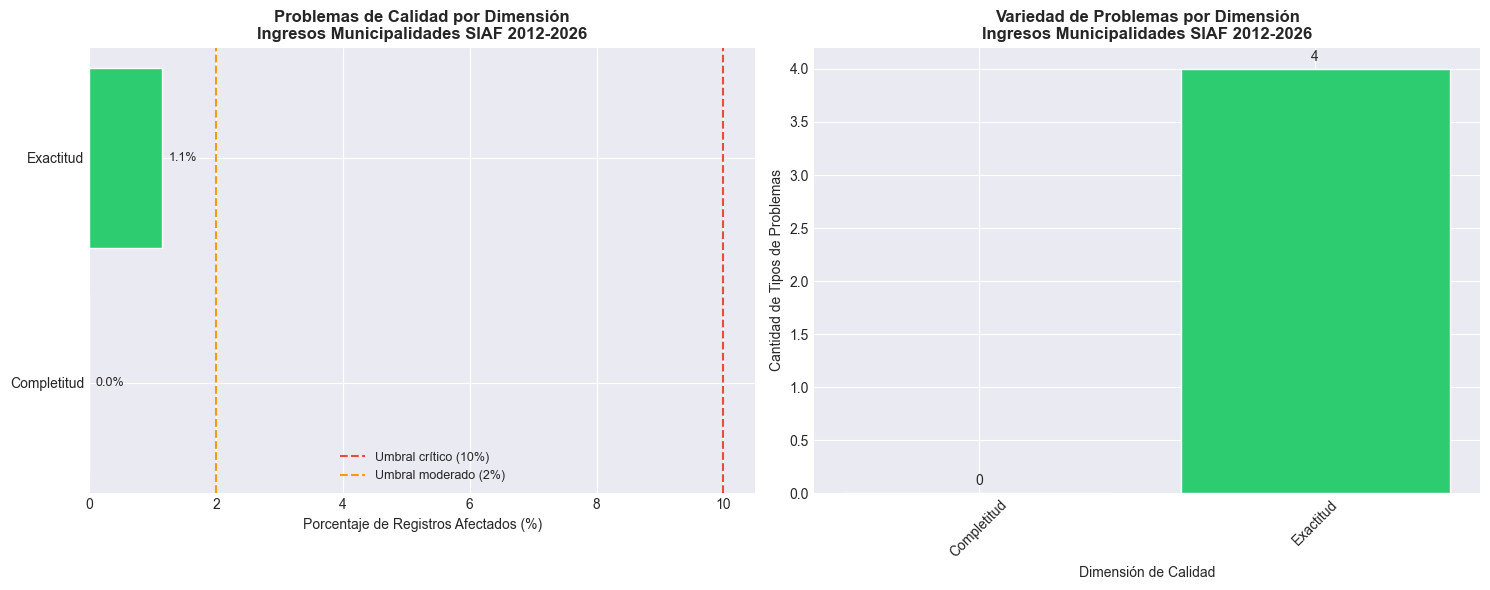

In [10]:
# Generar reporte consolidado de calidad
reporte = gestor.generar_reporte_consolidado()

print("=" * 65)
print("   REPORTE CONSOLIDADO DE CALIDAD DE DATOS")
print("   Ingresos Municipalidades SIAF 2012-2026")
print("=" * 65)
print(f"\nTotal registros analizados: {len(df_munic):,}")
print()
print(reporte.to_string(index=False))

# Puntaje global
puntaje = 100 - reporte['Porcentaje'].mean()
print(f"\n{'=' * 65}")
print(f"📊 PUNTAJE GLOBAL DE CALIDAD : {puntaje:.1f} / 100")
if puntaje >= 90:
    print("   🟢 Calidad ALTA — datos listos para Silver con ajustes menores")
elif puntaje >= 75:
    print("   🟡 Calidad MEDIA — requiere limpieza antes de pasar a Silver")
else:
    print("   🔴 Calidad BAJA — requiere limpieza exhaustiva antes de Silver")
print(f"{'=' * 65}")

# Visualizar resultados
gestor.visualizar_resultados()

## Análisis Detallado por Dimensión

El sistema permite acceder a los registros problemáticos específicos:

In [11]:
# Ejemplos de problemas de EXACTITUD - Ingresos Municipalidades SIAF
if 'Exactitud' in resultados:
    print("=" * 60)
    print("   DETALLE DE PROBLEMAS — EXACTITUD")
    print("   Ingresos Municipalidades SIAF 2012-2026")
    print("=" * 60)

    columnas_muestra = [
        'ANO_DOC', 'MES_DOC', 'EJECUTORA_NOMBRE',
        'RUBRO_NOMBRE', 'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
    ]

    hay_problemas = False

    for resultado in resultados['Exactitud']:
        if resultado.cantidad_problemas > 0:
            hay_problemas = True
            icono = (
                "🔴" if resultado.severidad == "ALTA"
                else "🟡" if resultado.severidad == "MEDIA"
                else "🟢"
            )
            print(f"\n{icono} {resultado.descripcion}")
            print(f"   Registros afectados: {resultado.cantidad_problemas:,} "
                  f"({resultado.porcentaje_afectado:.2f}%)")
            print(f"   Severidad          : {resultado.severidad}")
            print(f"\n   Muestra de registros:")
            print("-" * 60)

            # Mostrar solo columnas disponibles
            cols_disponibles = [
                c for c in columnas_muestra
                if c in resultado.registros_problematicos.columns
            ]
            print(resultado.registros_problematicos[
                cols_disponibles
            ].head().to_string(index=False))
            print()

    if not hay_problemas:
        print("\n✅ No se encontraron problemas de exactitud en los "
              "montos presupuestales de municipalidades.")

   DETALLE DE PROBLEMAS — EXACTITUD
   Ingresos Municipalidades SIAF 2012-2026

🔴 MONTO_PIM negativos: presupuesto modificado no puede ser negativo
   Registros afectados: 13,503 (0.15%)
   Severidad          : ALTA

   Muestra de registros:
------------------------------------------------------------
 ANO_DOC  MES_DOC                        EJECUTORA_NOMBRE                                                     RUBRO_NOMBRE  MONTO_PIA  MONTO_PIM  MONTO_RECAUDADO
    2014        4 MUNICIPALIDAD DISTRITAL DE LONYA GRANDE                                  FONDO DE COMPENSACION MUNICIPAL          0     -35654              0.0
    2014        4       MUNICIPALIDAD PROVINCIAL DE HUARI CANON Y SOBRECANON, REGALIAS, RENTA DE ADUANAS Y PARTICIPACIONES          0   -7511203              0.0
    2014       12      MUNICIPALIDAD DISTRITAL DE HUACHIS                                 RECURSOS DIRECTAMENTE RECAUDADOS          0         -1              0.0
    2014        1        MUNICIPALIDAD DISTRITAL 